# CICIDS2017 Preprocessing Notebook
This notebook prepares raw CICIDS2017 flow CSV files for downstream IDS experiments.

## What this notebook does
1. Loads and merges all raw MachineLearningCVE CSV files.
2. Standardizes column names and checks label distribution.
3. Removes duplicate and invalid rows (including inf/NaN handling).
4. Encodes labels and scales numeric features.
5. Splits data into train and test sets.
6. Generates class distribution and correlation plots.
7. Saves the cleaned dataset for reuse.

## Reproducibility notes
- Keep raw files under `../data_raw/cic-ids-2017/MachineLearningCVE/`.
- Run cells in order from top to bottom.
- If `Label` access fails, run the column strip cell before label inspection.

In [25]:
import pandas as pd
import glob

files = glob.glob("../data_raw/cic-ids-2017/MachineLearningCVE/*.csv")

print(len(files))   # should print number of CSV files

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df.head()

8


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


## Step A: Validate Raw Schema and Labels
These cells inspect folder contents, print column names, and check label frequencies.
This is important because CICIDS raw headers can contain leading spaces (for example ` Label`).

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [27]:
import os
os.listdir("../data_raw/cic-ids-2017")

['.DS_Store', 'MachineLearningCVE']

In [28]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [29]:
df[" Label"].value_counts()

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [30]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [31]:
df.columns = df.columns.str.strip()

In [32]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [33]:
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [34]:
df = df.drop_duplicates()

## Step B: Data Cleaning and Numeric Preparation
This section removes duplicate rows, handles infinite/missing values, and prepares data for ML transformations.
The goal is to avoid unstable model behavior caused by invalid feature values.

In [35]:
import numpy as np

df = df.copy()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Label"] = le.fit_transform(df["Label"])

In [37]:
df["Label"].value_counts()

Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns
# Exclude Label from scaling
num_cols = num_cols.drop("Label")

df[num_cols] = scaler.fit_transform(df[num_cols])

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y 
)

## Step C: Split, Visualize, and Export
After splitting into train/test sets, plots are generated to explain class balance and feature relationships.
The final cell saves the cleaned dataset for reuse by training pipelines.

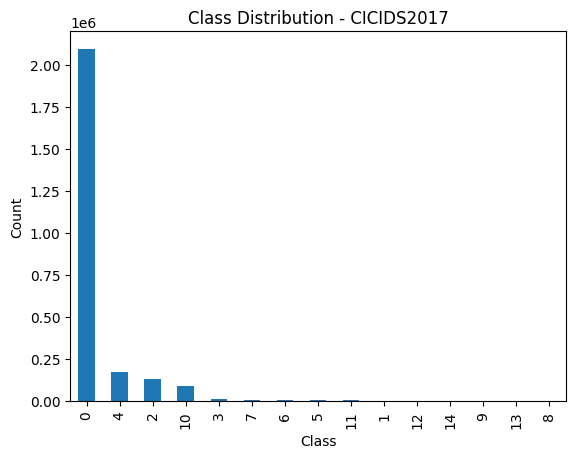

In [40]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar")

plt.title("Class Distribution - CICIDS2017")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

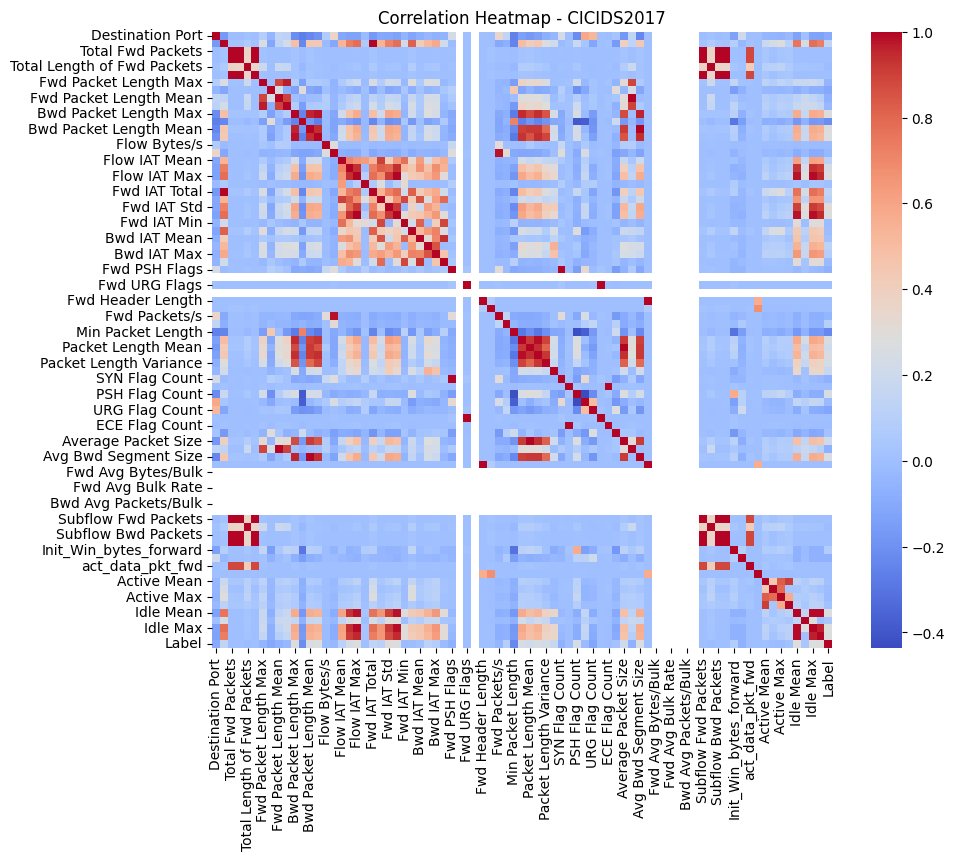

In [41]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap - CICIDS2017")

plt.show()

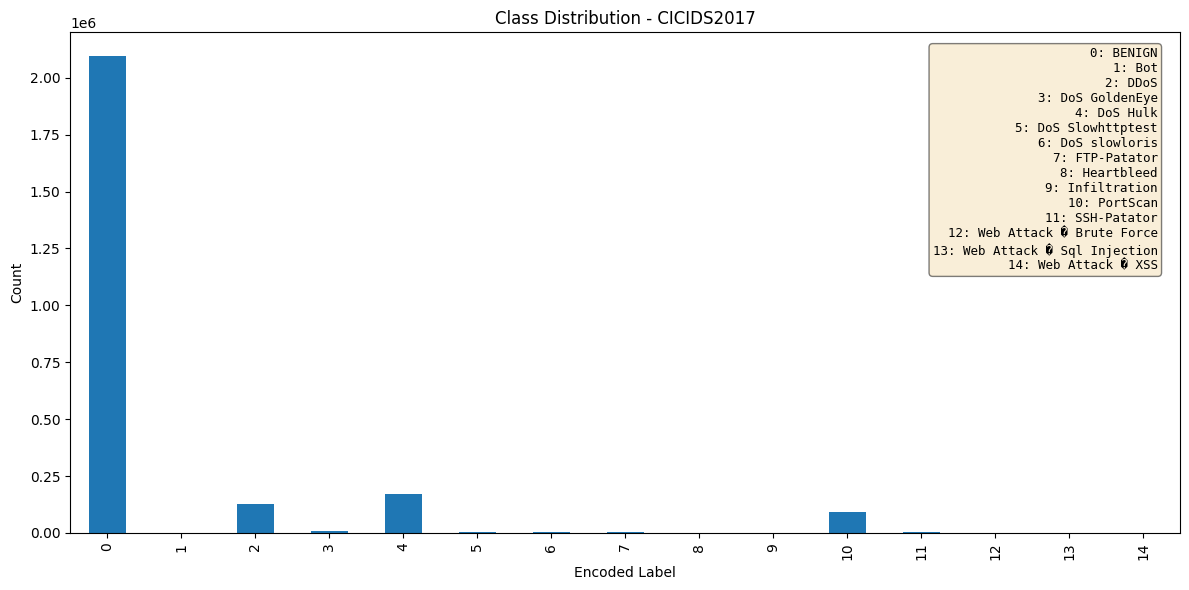

In [42]:
import matplotlib.pyplot as plt

# Create a mapping from encoded labels back to original names
label_mapping = dict(enumerate(le.classes_))

# Get value counts and map numeric labels back to names
value_counts = df["Label"].value_counts().sort_index()
labels_with_names = [label_mapping[i] for i in value_counts.index]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
value_counts.plot(kind="bar", ax=ax)

ax.set_title("Class Distribution - CICIDS2017")
ax.set_xlabel("Encoded Label")
ax.set_ylabel("Count")

# Add legend showing the mapping
legend_text = "\n".join([f"{i}: {label_mapping[i]}" for i in sorted(label_mapping.keys())])
ax.text(0.98, 0.97, legend_text, transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=9, family='monospace')

plt.tight_layout()
plt.show()

In [43]:
# Minority class percentage and imbalance ratio report
# Make this cell runnable on its own if df is not already in memory.
import os
import glob
import pandas as pd

if "df" not in globals():
    cleaned_path = "../data_processed/cicids2017_cleaned.csv"
    if os.path.exists(cleaned_path):
        df = pd.read_csv(cleaned_path)
    else:
        files = glob.glob("../data_raw/cic-ids-2017/MachineLearningCVE/*.csv")
        if not files:
            raise FileNotFoundError("CICIDS2017 source files not found in ../data_raw/cic-ids-2017/MachineLearningCVE/")
        df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        df.columns = df.columns.str.strip()

label_col = "Label" if "Label" in df.columns else "label" if "label" in df.columns else None
if label_col is None:
    raise KeyError("No label column found. Expected 'Label' or 'label'.")

class_counts = df[label_col].value_counts().sort_values(ascending=False)

total_samples = class_counts.sum()
minority_class = class_counts.idxmin()
minority_count = class_counts.min()
majority_count = class_counts.max()

minority_percentage = (minority_count / total_samples) * 100
imbalance_ratio = majority_count / minority_count

class_report = (class_counts / total_samples * 100).rename("percentage").reset_index()
class_report.columns = ["class", "percentage"]

print("Minority class:", minority_class)
print("Minority class count:", minority_count)
print("Minority class percentage: {:.4f}%".format(minority_percentage))
print("Imbalance ratio (majority/minority): {:.4f}".format(imbalance_ratio))

class_report

Minority class: 8
Minority class count: 11
Minority class percentage: 0.0004%
Imbalance ratio (majority/minority): 190459.7273


,class,percentage
0,0,83.110864
1,4,6.856797
2,2,5.078313
3,10,3.597829
4,3,0.408045
5,7,0.235283
6,6,0.213623
7,5,0.207395
8,11,0.127698
9,1,0.077277


In [44]:
df.to_csv("../data_processed/cicids2017_cleaned.csv", index=False)